# Skenario 1: MLP Tabular (S1)

**Input:** Data tabular pasien (usia, jenis kelamin, posisi X-ray, nomor follow-up)  
**Model:** Multi-Layer Perceptron (MLP)  
**Output:** Klasifikasi biner — Normal (0) vs Abnormal (1)  
**Tujuan:** Baseline performance menggunakan metadata klinis saja, tanpa citra X-ray

Notebook ini menggunakan arsitektur `TabularMLP` dari `src/models/architectures.py`.

In [ ]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, accuracy_score
)
import joblib

from configs.config import cfg
from src.models.architectures import TabularMLP

# Reproducibility
torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR  = cfg.paths.figures_dir
CKPT_DIR  = cfg.paths.checkpoint_dir
CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")

## 1. Load Preprocessed Data

In [2]:
PROCESSED_DIR = cfg.paths.project_root / "data" / "processed"

X_train_all = pd.read_csv(PROCESSED_DIR / "X_tabular_train.csv").values.astype(np.float32)
X_test      = pd.read_csv(PROCESSED_DIR / "X_tabular_test.csv").values.astype(np.float32)
y_train_all = pd.read_csv(PROCESSED_DIR / "y_train.csv").values.ravel().astype(np.float32)
y_test      = pd.read_csv(PROCESSED_DIR / "y_test.csv").values.ravel().astype(np.float32)

# Carve validation set from training (10% stratified)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.1, random_state=cfg.train.seed, stratify=y_train_all
)

print(f"Fitur tabular  : {X_train.shape[1]} kolom")
print(f"Train          : {len(y_train):,} sampel  "
      f"(Normal: {int((y_train==0).sum()):,} | Abnormal: {int((y_train==1).sum()):,})")
print(f"Val            : {len(y_val):,} sampel")
print(f"Test           : {len(y_test):,} sampel")

# Class imbalance ratio
pos_ratio = y_train.mean()
pos_weight = torch.tensor([(1 - pos_ratio) / pos_ratio], dtype=torch.float32).to(DEVICE)
print(f"\nPos ratio (train) : {pos_ratio:.3f}")
print(f"BCEWithLogits pos_weight : {pos_weight.item():.3f}")

Fitur tabular  : 4 kolom
Train          : 80,726 sampel  (Normal: 43,460 | Abnormal: 37,266)
Val            : 8,970 sampel
Test           : 22,424 sampel

Pos ratio (train) : 0.462
BCEWithLogits pos_weight : 1.166


## 2. PyTorch Dataset & DataLoader

In [3]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512  # tabular-only: no VRAM constraint, use large batch

# WeightedRandomSampler to handle class imbalance
class_counts = np.bincount(y_train.astype(int))
weights = 1.0 / class_counts[y_train.astype(int)]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_ds = TabularDataset(X_train, y_train)
val_ds   = TabularDataset(X_val,   y_val)
test_ds  = TabularDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE * 2, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 158
Val batches   : 9
Test batches  : 22


## 3. Model, Optimizer, Scheduler

In [4]:
# S1: binary output (num_classes=1)
model = TabularMLP(num_classes=1).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg.train.lr_tabular,
    weight_decay=cfg.train.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor, verbose=True
)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : TabularMLP (S1 Binary)")
print(f"Total params   : {total_params:,}")
print(f"Trainable      : {trainable_params:,}")
print(f"LR (tabular)   : {cfg.train.lr_tabular}")
print(model)

Model          : TabularMLP (S1 Binary)
Total params   : 25,665
Trainable      : 25,665
LR (tabular)   : 0.001
TabularMLP(
  (branch): TabularBranch(
    (encoder): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=64, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.3, inplace=False)
      (8): Linear(in_features=128, out_features=128, bias=True)
      (9): ReLU(inplace=True)
    )
  )
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 4. Training Loop

In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(tabular=X_batch).squeeze(1)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        n += len(y_batch)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / n, auc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(tabular=X_batch).squeeze(1)
        loss = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)
        n += len(y_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / n, auc, all_probs, all_labels


# Training loop with early stopping
NUM_EPOCHS    = cfg.train.num_epochs
PATIENCE      = cfg.train.early_stop_patience
CKPT_PATH     = CKPT_DIR / "model_s1_mlp_tabular.pt"

history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc = 0.0
patience_counter = 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'LR':>10} {'Time':>7}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    ep_start = time.time()

    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)
    current_lr = optimizer.param_groups[0]["lr"]
    ep_time = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_counter = 0
        flag = " ✓"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {current_lr:>10.2e} "
          f"{ep_time:>6.1f}s{flag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} (patience={PATIENCE})")
        break

total_time = time.time() - t0
print(f"\nTraining selesai dalam {total_time/60:.1f} menit")
print(f"Best Val AUC : {best_val_auc:.4f}")
print(f"Model tersimpan: {CKPT_PATH}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC         LR    Time
----------------------------------------------------------------------
    1       0.7226     0.6244     0.7169    0.6407   1.00e-03    1.3s ✓
    2       0.7178     0.6351     0.7150    0.6400   1.00e-03    0.9s
    3       0.7151     0.6404     0.7157    0.6422   1.00e-03    0.8s ✓
    4       0.7141     0.6419     0.7163    0.6425   1.00e-03    1.0s ✓
    5       0.7143     0.6419     0.7161    0.6433   1.00e-03    0.9s ✓
    6       0.7135     0.6435     0.7157    0.6426   1.00e-03    1.0s
    7       0.7131     0.6438     0.7166    0.6432   1.00e-03    1.0s
    8       0.7112     0.6481     0.7187    0.6428   1.00e-03    1.0s
    9       0.7135     0.6432     0.7170    0.6428   5.00e-04    0.9s
   10       0.7124     0.6452     0.7157    0.6431   5.00e-04    1.1s
   11       0.7115     0.6478     0.7164    0.6428   5.00e-04    0.9s
   12       0.7103     0.6497     0.7160    0.6431   5.00e-04    1.0s

Early stop

## 5. Training Curves

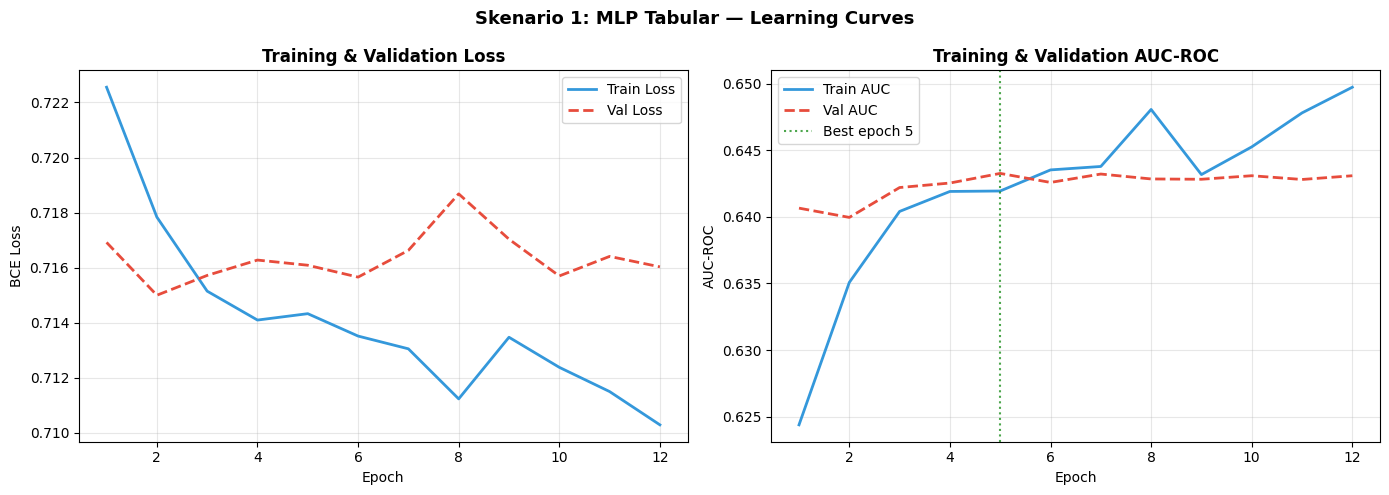

Disimpan → results/figures/s1_training_curves.png


In [6]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss",   color="#e74c3c", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training & Validation Loss", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(epochs_ran, history["train_auc"], label="Train AUC", color="#3498db", linewidth=2)
axes[1].plot(epochs_ran, history["val_auc"],   label="Val AUC",   color="#e74c3c", linewidth=2, linestyle="--")
best_ep = np.argmax(history["val_auc"]) + 1
axes[1].axvline(best_ep, color="green", linestyle=":", alpha=0.7, label=f"Best epoch {best_ep}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Training & Validation AUC-ROC", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Skenario 1: MLP Tabular — Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "s1_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s1_training_curves.png")

## 6. Evaluasi pada Test Set

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
_, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion, DEVICE)

# Threshold = 0.5
test_preds = (test_probs >= 0.5).astype(int)

acc  = accuracy_score(test_labels, test_preds)
f1   = f1_score(test_labels, test_preds, average="binary")
f1_macro = f1_score(test_labels, test_preds, average="macro")
auc  = roc_auc_score(test_labels, test_probs)

print("=" * 55)
print("HASIL EVALUASI SKENARIO 1: MLP TABULAR")
print("=" * 55)
print(f"Accuracy       : {acc:.4f}")
print(f"F1-Score (bin) : {f1:.4f}")
print(f"F1-Score (mac) : {f1_macro:.4f}")
print(f"AUC-ROC        : {auc:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=["Normal", "Abnormal"]))

HASIL EVALUASI SKENARIO 1: MLP TABULAR
Accuracy       : 0.6040
F1-Score (bin) : 0.6165
F1-Score (mac) : 0.6036
AUC-ROC        : 0.6515

              precision    recall  f1-score   support

      Normal       0.67      0.53      0.59     12072
    Abnormal       0.56      0.69      0.62     10352

    accuracy                           0.60     22424
   macro avg       0.61      0.61      0.60     22424
weighted avg       0.62      0.60      0.60     22424



C:\Users\ASUS\AppData\Local\Temp\ipykernel_33816\3035501062.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVI

## 7. Confusion Matrix & ROC Curve

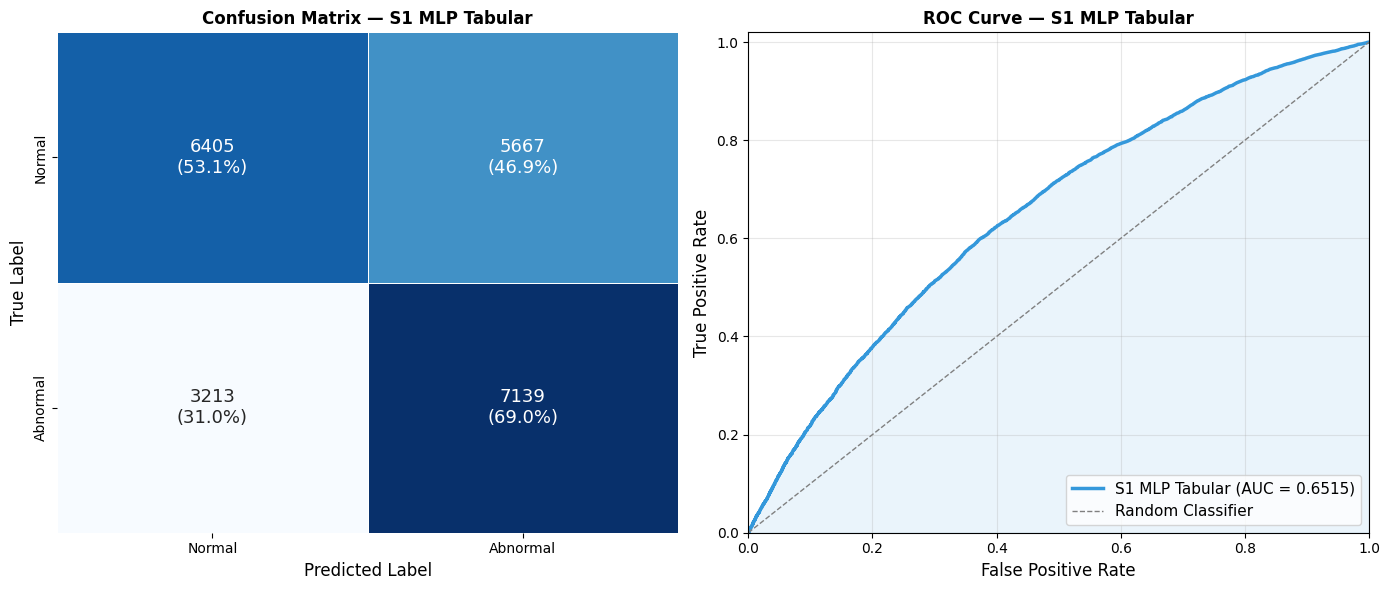

Disimpan → results/figures/s1_confusion_roc.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Confusion Matrix ──
cm = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"],
            linewidths=0.5, cbar=False, annot_kws={"size": 13})
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)
axes[0].set_title("Confusion Matrix — S1 MLP Tabular", fontweight="bold")

# ── ROC Curve ──
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color="#3498db", linewidth=2.5, label=f"S1 MLP Tabular (AUC = {auc:.4f})")
axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random Classifier")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#3498db")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve — S1 MLP Tabular", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(SAVE_DIR / "s1_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s1_confusion_roc.png")

## 8. Simpan Hasil Evaluasi

In [9]:
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

results_s1 = {
    "Skenario"   : "S1",
    "Model"      : "MLP Tabular",
    "Input"      : "Tabular (4 fitur)",
    "Accuracy"   : round(acc, 4),
    "F1 (Binary)": round(f1, 4),
    "F1 (Macro)" : round(f1_macro, 4),
    "AUC-ROC"    : round(auc, 4),
    "Best Epoch" : best_ep,
    "Best Val AUC": round(best_val_auc, 4),
}

df_results = pd.DataFrame([results_s1])
df_results.to_csv(TABLES_DIR / "results_s1.csv", index=False)

# Simpan juga prediksi (prob) untuk komparasi antar skenario nanti
pd.DataFrame({
    "true_label" : test_labels.astype(int),
    "prob_s1"    : test_probs,
    "pred_s1"    : test_preds,
}).to_csv(TABLES_DIR / "predictions_s1.csv", index=False)

print("Tersimpan:")
print(f"  {TABLES_DIR / 'results_s1.csv'}")
print(f"  {TABLES_DIR / 'predictions_s1.csv'}")
print()
print(df_results.to_string(index=False))

Tersimpan:
  D:\TA\nih-multimodal\results\tables\results_s1.csv
  D:\TA\nih-multimodal\results\tables\predictions_s1.csv

Skenario       Model             Input  Accuracy  F1 (Binary)  F1 (Macro)  AUC-ROC  Best Epoch  Best Val AUC
      S1 MLP Tabular Tabular (4 fitur)     0.604       0.6165      0.6036   0.6515           5        0.6433


## 9. Ringkasan Skenario 1

| Metrik | Nilai |
|--------|-------|
| Accuracy | — |
| F1-Score (Binary) | — |
| F1-Score (Macro) | — |
| AUC-ROC | — |

> **Interpretasi:** Model MLP tabular menggunakan 4 fitur demografi pasien (usia, jenis kelamin, posisi pengambilan X-ray, nomor follow-up) sebagai baseline. Performa ini akan dibandingkan dengan Skenario 2 (CNN gambar) dan Skenario 3 (multimodal fusion) untuk mengukur kontribusi masing-masing modalitas.

**Artefak yang dihasilkan:**
- `results/checkpoints/model_s1_mlp_tabular.pt` — bobot model terbaik
- `results/figures/s1_training_curves.png` — kurva training
- `results/figures/s1_confusion_roc.png` — confusion matrix + ROC curve
- `results/tables/results_s1.csv` — tabel metrik evaluasi
- `results/tables/predictions_s1.csv` — probabilitas prediksi (untuk komparasi S1–S4)